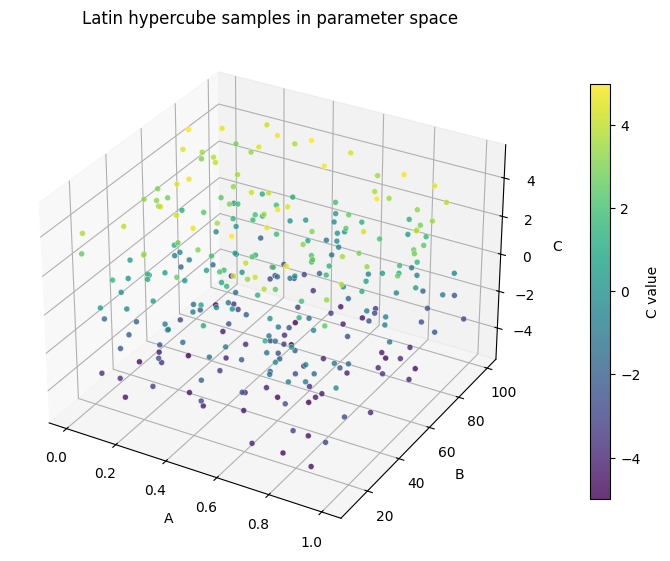

In [1]:
import numpy as np
from scipy.stats import qmc
import matplotlib.pyplot as plt

# 1) parameter ranges: [low, high] per variable
bounds = np.array([
    [0.0, 1.0],     # param A
    [10.0, 100.0],  # param B
    [-5.0, 5.0],    # param C
])
d = bounds.shape[0]
N = 300  # try 10–20×d and scale up as needed

# 2) Latin hypercube sample in [0,1]^d, then scale to bounds
sampler = qmc.LatinHypercube(d)
X01 = sampler.random(N)
X = qmc.scale(X01, bounds[:,0], bounds[:,1])  # shape (N, d)

# 3) visualize the sampled points in 3D (A, B, C)
fig3d = plt.figure(figsize=(7.5, 5.5), constrained_layout=True)
ax3d = fig3d.add_subplot(111, projection="3d")

sc = ax3d.scatter(
    X[:, 0], X[:, 1], X[:, 2],
    c=X[:, 2], cmap="viridis",
    s=18, alpha=0.8, edgecolor="white", linewidth=0.3,
)

ax3d.set_xlabel("A")
ax3d.set_ylabel("B")
ax3d.set_zlabel("C")
ax3d.set_title("Latin hypercube samples in parameter space")
cb = plt.colorbar(sc, ax=ax3d, pad=0.1, shrink=0.8)
cb.set_label("C value")

plt.show()

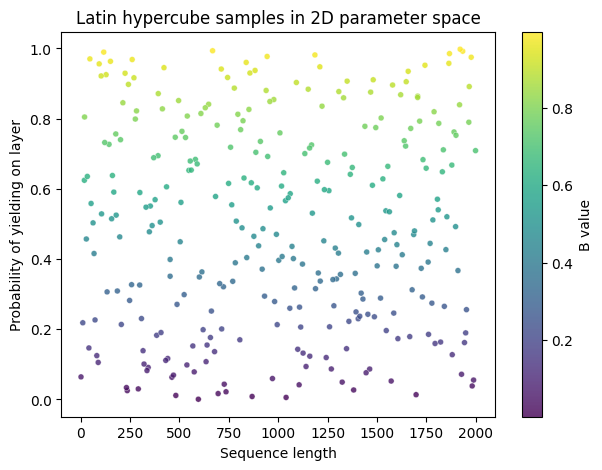

In [7]:
# 2D Latin hypercube sampling using the same approach
bounds_2d = np.array([
    [0.0, 2000.0],     # param A
    [0.0, 1.0],  # param B
])
d2 = bounds_2d.shape[0]
N2 = 300

sampler2d = qmc.LatinHypercube(d2)
X01_2d = sampler2d.random(N2)
X_2d = qmc.scale(X01_2d, bounds_2d[:,0], bounds_2d[:,1])

# Convert the first dimension to integers by flooring them for X_2d
X_2d[:, 0] = np.floor(X_2d[:, 0])

# Visualize the 2D samples
plt.figure(figsize=(7, 5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=X_2d[:, 1], cmap="viridis", s=18, alpha=0.8, edgecolor="white", linewidth=0.3)
plt.xlabel("Sequence length")
plt.ylabel("Probability of yielding on layer")
plt.title("Latin hypercube samples in 2D parameter space")
plt.colorbar(label="Yield Ratio")
plt.show()